# <span style="color: rgba(230, 0, 126, 1);"> DESAFÍO 2 </span> #

## <span style="color: rgba(230, 0, 126, 1);"> Analistas de Finanzas y Riesgo Creditício </span> ##

### <span style="color: rgba(230, 0, 126, 1);"> 1.- Enunciado </span> ###
- Los clientes con prestamos e hipotecas tienden a tener un saldo mediano mas bajo o mas riesgo de incumplimiento?
- Como tenemos que ajustar nuestras ofertas y estrategias de gestion de riesgos?

### <span style="color: rgba(230, 0, 126, 1);"> Importación de librerias para el análisis de datos </span> ###

In [2]:
# importación de librerias para el análisis de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### <span style="color: rgba(230, 0, 126, 1);"> Carga de datos desde archivo CSV original </span> ###

In [3]:
# la r al inicio cambia el sentido de la contrabarra en el path del repositorio local copiada directamente del explorador de windows. sep0";" indica como están separados los campos en el archivo csv"
df = pd.read_csv(
    r"C:\Users\mange\OneDrive\Cursos\Analisis de datos\Simulador\ProjecteData\Equip_18\Data\031125dataset.csv",
    sep=';'
)
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000
mean,9696.708514,41.312152,1535.302067,15.671885,370.811533,2.513055,51.420864,0.834241
std,6754.510024,11.927441,3292.261675,8.438361,347.467998,2.736740,109.471445,2.287959
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,4041.250000,32.000000,124.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,8081.500000,39.000000,556.000000,15.000000,254.000000,2.000000,-1.000000,0.000000
75%,17342.750000,49.000000,1708.000000,22.000000,494.000000,3.000000,9.000000,1.000000
max,21383.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### <span style="color: rgba(230, 0, 126, 1);"> EDA </span> ###

In [4]:
df['default'].value_counts()

default
no     15920
yes      242
Name: count, dtype: int64

In [5]:
df['balance'].describe()

count    16162.000000
mean      1535.302067
std       3292.261675
min      -6847.000000
25%        124.000000
50%        556.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

In [6]:
print("Nulos:", df['housing'].isna().sum())
print('"unknown":', (df['housing'] == 'unknown').sum())
print("\nDistribución de valores:")
print(df['housing'].value_counts(dropna=False))


Nulos: 0
"unknown": 0

Distribución de valores:
housing
no     8558
yes    7604
Name: count, dtype: int64


C:\Users\mange\AppData\Local\Temp\ipykernel_5868\1847034575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='balance', data=df,palette="Set2")


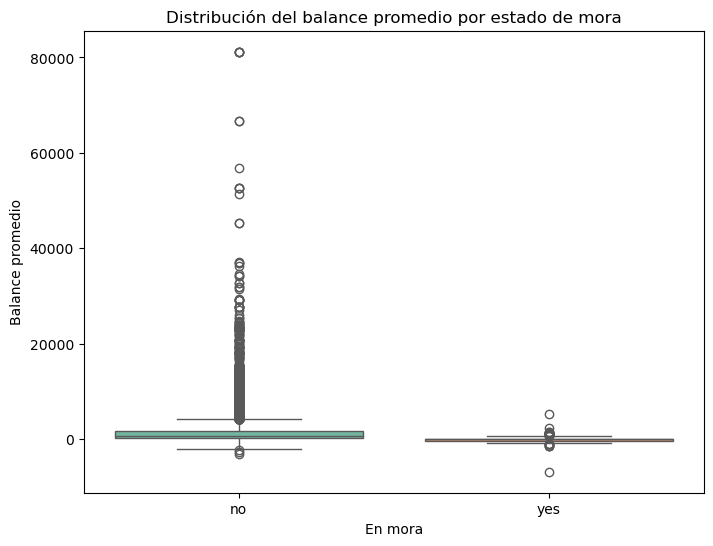

In [7]:
plt.figure(figsize=(8,6))
sns.boxplot(x='default', y='balance', data=df,palette="Set2")
plt.title("Distribución del balance promedio por estado de mora")
plt.xlabel("En mora")
plt.ylabel("Balance promedio")
plt.show();


### <span style="color: rgba(230, 0, 126, 1);"> Correlación </span> ###

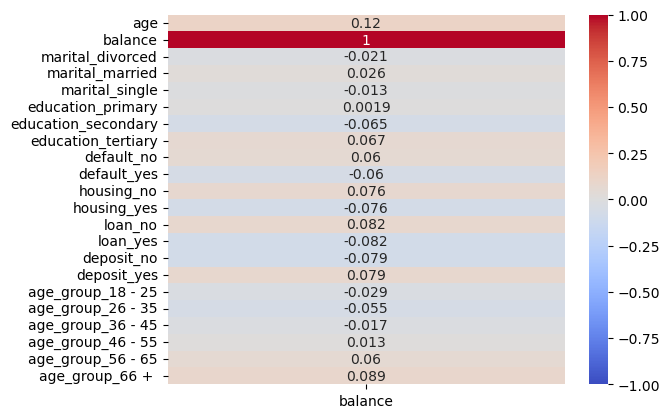

In [8]:
sns.heatmap(pd.get_dummies(df.drop(columns = ["id","contact","job","day","month", "duration","campaign","pdays","previous","poutcome"])).corr()[["balance"]],
            annot=True,           # esto me ayuda a mostrar los coeficientes
            cmap='coolwarm',      # paleta de colores
            vmin=-1, vmax=1);      # aca defino la escala de correlacion

In [9]:
neg = df[(df['balance'] < 0) & (df['default'] == 'yes')].shape[0]
no_neg = df[(df['balance'] >= 0) & (df['default'] == 'yes')].shape[0]
total_neg = df[df['balance'] < 0].shape[0]
total_no_neg = df[(df['balance'] >= 0) ].shape[0]

tasa_neg = neg / total_neg * 100
tasa_no_neg = no_neg / total_no_neg * 100




print(f"Número total de clientes con balance negativo: {total_neg:.2f}")
print(f"Número de clientes con balance negativo y mora: {neg:.2f}")
print()
print(f"Número total de clientes con balance positivo: {total_no_neg:.2f}")
print(f"Número de clientes con balance positivo y mora: {no_neg:.2f}")
print()
print(f"Tasa de mora con saldo negativo: {tasa_neg:.2f}%")
print(f"Tasa de mora con saldo positivo: {tasa_no_neg:.2f}%")


Número total de clientes con balance negativo: 1004.00
Número de clientes con balance negativo y mora: 111.00

Número total de clientes con balance positivo: 15158.00
Número de clientes con balance positivo y mora: 131.00

Tasa de mora con saldo negativo: 11.06%
Tasa de mora con saldo positivo: 0.86%


In [10]:
# Definir los límites de los rangos
bins = [-float('inf'), -0.000001, 500, 2000, 10000]
labels = ['Negativo', 'Bajo', 'Medio', 'Alto']

# Crear la columna categórica
df['rango_balance'] = pd.cut(df['balance'], bins=bins, labels=labels)

# Verificar cuántos clientes hay en cada categoría
print(df['rango_balance'].value_counts())


rango_balance
Bajo        6716
Medio       4906
Alto        3209
Negativo    1004
Name: count, dtype: int64


In [18]:
tasa_mora = pd.crosstab(df['rango_balance'], df['default'], normalize='index') * 100
print(tasa_mora)

default               no        yes
rango_balance                      
Negativo       88.944223  11.055777
Bajo           98.362120   1.637880
Medio          99.612719   0.387281
Alto           99.937675   0.062325


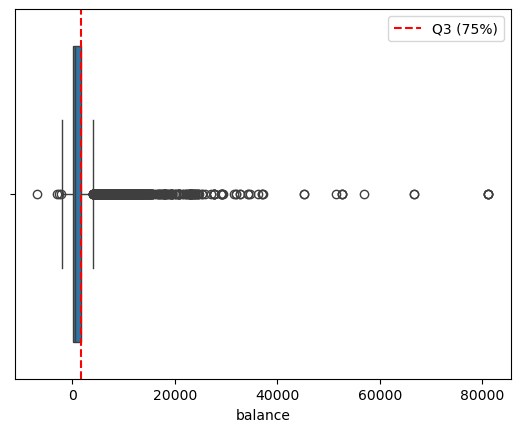

In [11]:

sns.boxplot(x=df['balance'])
plt.axvline(df['balance'].quantile(0.75), color='red', linestyle='--', label='Q3 (75%)')
plt.legend()
plt.show()


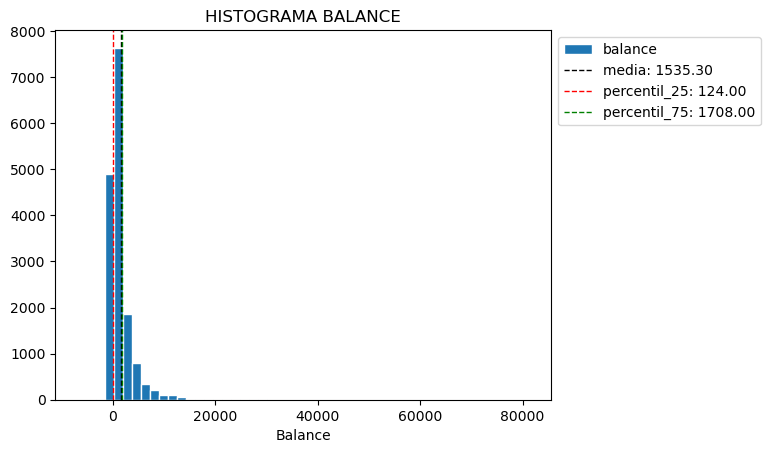

In [12]:
# Calculo las 4 medidas estadísticas básicas a partir del balance

media=df["balance"].mean()
mediana=df["balance"].median()
percentil_25=np.percentile(df["balance"],25)
percentil_75=np.percentile(df["balance"],75)

# Gráfica en la que se muestran el histográma que representa a la variable numérica "amount"
df["balance"].plot.hist(bins=50,edgecolor="white",label="balance")

# Lineas auxilliares sobre el gráfico
plt.axvline(media, color='black', linestyle='dashed', linewidth=1, label=f'media: {media:.2f}')
plt.axvline(percentil_25, color='red', linestyle='dashed', linewidth=1, label=f'percentil_25: {percentil_25:.2f}')
plt.axvline(percentil_75, color='green', linestyle='dashed', linewidth=1, label=f'percentil_75: {percentil_75:.2f}')

# Configuración de las etiquetas de los ejes y de la leyenda
plt.title("HISTOGRAMA BALANCE")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("Balance")
plt.ylabel("");

### <span style="color: rgba(230, 0, 126, 1);"> Cantidad de clientes por tipo de productos </span> ###

In [13]:



total_clientes = df.shape[0]

solo_housing = df[(df['housing'] == 'yes') & (df['loan'] == 'no')].shape[0]

solo_loan = df[(df['housing'] == 'no') & (df['loan'] == 'yes')].shape[0]


housing_loan = df[(df['housing'] == 'yes') & (df['loan'] == 'yes')].shape[0]


ninguno = df[(df['housing'] == 'no') & (df['loan'] == 'no')].shape[0]


resumen = pd.DataFrame({
    'Categoria': ['Solo Housing', 'Solo Loan', 'Housing y Loan', 'Ninguno'],
    'Clientes': [solo_housing, solo_loan, housing_loan, ninguno]
})


resumen['Porcentaje'] = (resumen['Clientes'] / total_clientes * 100).round(2)


print(f"Total clientes: {total_clientes}")
print(resumen)


Total clientes: 16162
        Categoria  Clientes  Porcentaje
0    Solo Housing      6395       39.57
1       Solo Loan       915        5.66
2  Housing y Loan      1209        7.48
3         Ninguno      7643       47.29


### <span style="color: rgba(230, 0, 126, 1);"> Histograma de Balance </span> ###

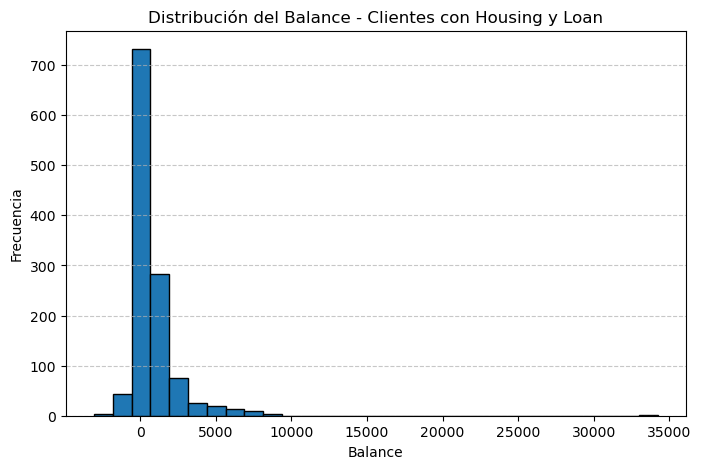

In [14]:

df_ambos = df[(df['housing'] == 'yes') & (df['loan'] == 'yes')]

# Crear histograma del balance
plt.figure(figsize=(8,5))
plt.hist(df_ambos['balance'], bins=30, edgecolor='black')
plt.title('Distribución del Balance - Clientes con Housing y Loan')
plt.xlabel('Balance')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### <span style="color: rgba(230, 0, 126, 1);"> Calculo tasas por rango y producto</span> ###

In [15]:
#Creacion de dataframes
df_ninguno = df[(df['housing'] == 'no') & (df['loan'] == 'no')].copy()
df_loan = df[(df['loan'] == 'yes') & (df['housing'] == 'no')].copy()
df_housing = df[(df['housing'] == 'yes') & (df['loan'] == 'no')].copy()
df_ambos = df[(df['housing'] == 'yes') & (df['loan'] == 'yes')].copy()

df_ninguno.loc[:, 'Grupo'] = 'Sin productos'
df_loan.loc[:, 'Grupo'] = 'Solo loan'
df_housing.loc[:, 'Grupo'] = 'Solo housing'
df_ambos.loc[:, 'Grupo'] = 'Housing y loan'

# hacer solo un dataframe
df_all = pd.concat([df_ninguno, df_loan, df_housing, df_ambos], ignore_index=True)

# Clasificar el balance en rangos
bins = [-float('inf'), -0.000001, 500, 2000, 10000]
labels = ['Negativo', 'Bajo', 'Medio', 'Alto']
df_all.loc[:, 'rango_balance'] = pd.cut(df_all['balance'], bins=bins, labels=labels)

# Crear tabla de frecuencias (conteo de mora y no mora)
tabla_frecuencias = (
    df_all.groupby(['Grupo', 'rango_balance', 'default'], observed=True)
          .size()
          .reset_index(name='conteo')
)

# formato ancho
tabla_frecuencias = (
    tabla_frecuencias
    .pivot_table(index=['Grupo', 'rango_balance'],
                 columns='default',
                 values='conteo',
                 fill_value=0,
                 observed=True)
    .reset_index()
)

# Renombrar columnas y calcular totales y tasas
tabla_frecuencias = tabla_frecuencias.rename(columns={'no': 'No mora', 'yes': 'Mora'})
tabla_frecuencias['Total'] = tabla_frecuencias['No mora'] + tabla_frecuencias['Mora']
tabla_frecuencias['Tasa mora (%)'] = (tabla_frecuencias['Mora'] / tabla_frecuencias['Total'] * 100).round(2)


print("📊 Tabla de frecuencias consolidada:")
print(tabla_frecuencias.to_string(index=False))


📊 Tabla de frecuencias consolidada:
         Grupo rango_balance  No mora  Mora  Total  Tasa mora (%)
Housing y loan      Negativo    177.0  22.0  199.0          11.06
Housing y loan          Bajo    496.0   9.0  505.0           1.78
Housing y loan         Medio    367.0   2.0  369.0           0.54
Housing y loan          Alto    134.0   0.0  134.0           0.00
 Sin productos      Negativo    118.0  17.0  135.0          12.59
 Sin productos          Bajo   3066.0  47.0 3113.0           1.51
 Sin productos         Medio   2326.0   8.0 2334.0           0.34
 Sin productos          Alto   1851.0   0.0 1851.0           0.00
  Solo housing      Negativo    489.0  56.0  545.0          10.28
  Solo housing          Bajo   2627.0  26.0 2653.0           0.98
  Solo housing         Medio   1960.0   6.0 1966.0           0.31
  Solo housing          Alto   1119.0   2.0 1121.0           0.18
     Solo loan      Negativo    109.0  16.0  125.0          12.80
     Solo loan          Bajo    417.0  2

### <span style="color: rgba(230, 0, 126, 1);"> Calculo Chi2</span> ###

In [16]:
from scipy.stats import chi2_contingency


resultados_chi2 = []

for rango in tabla_frecuencias['rango_balance'].unique():
    # Subconjunto por rango
    subset = tabla_frecuencias[tabla_frecuencias['rango_balance'] == rango]
    
    # Creamos la tabla de contingencia: filas = Grupo, columnas = Mora/No mora
    tabla_contingencia = subset[['Grupo', 'No mora', 'Mora']].set_index('Grupo')
    
    # Aplicar test Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    
    # Guardar resultados
    resultados_chi2.append({
        'Rango_balance': rango,
        'Chi2': round(chi2, 4),
        'p-valor': round(p, 6),
        'Grados_libertad': dof
    })

# Convertir a DataFrame para ver resultados juntos
resultados_chi2 = pd.DataFrame(resultados_chi2)

# Mostrar resultados
print("Resultados del test Chi-cuadrado por rango de balance:")
print(resultados_chi2.to_string(index=False))

# Interpretación simple
print("\n Interpretación:")
print("Si p-valor < 0.05 → existen diferencias significativas entre grupos (las tasas de mora difieren).")
print("Si p-valor >= 0.05 → no hay evidencia de diferencias significativas entre grupos.")


Resultados del test Chi-cuadrado por rango de balance:
Rango_balance    Chi2  p-valor  Grados_libertad
     Negativo  1.0486 0.789485                3
         Bajo 67.3433 0.000000                3
        Medio  5.4340 0.142638                3
         Alto  3.7276 0.292424                3

 Interpretación:
Si p-valor < 0.05 → existen diferencias significativas entre grupos (las tasas de mora difieren).
Si p-valor >= 0.05 → no hay evidencia de diferencias significativas entre grupos.


### <span style="color: rgba(230, 0, 126, 1);"> Calculo chi2 2X2</span> ###

In [17]:
from itertools import combinations
from scipy.stats import chi2_contingency
import pandas as pd

# Filtrar solo el rango de balance "Bajo"
df_bajo = tabla_frecuencias[tabla_frecuencias['rango_balance'] == 'Bajo']

# Crear todas las combinaciones posibles de grupos (pares)
pares = list(combinations(df_bajo['Grupo'].unique(), 2))

resultados_pares = []

for g1, g2 in pares:
    sub = df_bajo[df_bajo['Grupo'].isin([g1, g2])][['Grupo', 'No mora', 'Mora']]
    tabla = sub.set_index('Grupo')[['No mora', 'Mora']].values
    chi2, p, dof, _ = chi2_contingency(tabla)
    resultados_pares.append({
        'Comparación': f'{g1} vs {g2}',
        'Chi2': round(chi2, 4),
        'p-valor': p
    })

posthoc = pd.DataFrame(resultados_pares)
posthoc['Significativo (p<0.05)'] = posthoc['p-valor'] < 0.05

print("🔍 Comparaciones post hoc — rango de balance 'Bajo':")
print(posthoc.to_string(index=False))


🔍 Comparaciones post hoc — rango de balance 'Bajo':
                    Comparación    Chi2      p-valor  Significativo (p<0.05)
Housing y loan vs Sin productos  0.0706 7.905218e-01                   False
 Housing y loan vs Solo housing  1.8126 1.782013e-01                   False
    Housing y loan vs Solo loan 11.6776 6.325674e-04                    True
  Sin productos vs Solo housing  2.8061 9.390628e-02                   False
     Sin productos vs Solo loan 40.8665 1.629915e-10                    True
      Solo housing vs Solo loan 59.7244 1.091160e-14                    True
